In [8]:
import io
import time
import numpy as np
import mercantile
import requests
from PIL import Image
import rasterio
from rasterio.transform import from_bounds
from rasterio.mask import mask
import matplotlib.pyplot as plt

In [6]:
TILE_SIZE = 256
HEADERS = {
    # Google's tile servers often reject the default python-requests UA.
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/124.0 Safari/537.36"
    )
}
 
MAX_RETRIES = 3
RETRY_DELAY_S = 1.0
 
 
# ----------------------------------------------------------------------
# 1. Figure out which tiles cover the AOI
# ----------------------------------------------------------------------
 
def get_tile_list(bbox, zoom):
    west, south, east, north = bbox
    tiles = list(mercantile.tiles(west, south, east, north, [zoom]))
    if not tiles:
        raise ValueError("No tiles found for this bbox/zoom — check BBOX ordering.")
    xs = [t.x for t in tiles]
    ys = [t.y for t in tiles]
    return tiles, min(xs), max(xs), min(ys), max(ys)
 
 
# ----------------------------------------------------------------------
# 2. Download a single tile (with retries)
# ----------------------------------------------------------------------
 
def download_tile(x, y, z):
    url = TILE_URL.format(x=x, y=y, z=z)
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=15)
            resp.raise_for_status()
            img = Image.open(io.BytesIO(resp.content)).convert("RGB")
            if img.size != (TILE_SIZE, TILE_SIZE):
                img = img.resize((TILE_SIZE, TILE_SIZE))
            return img
        except Exception as e:
            if attempt == MAX_RETRIES:
                print(f"  Failed tile {z}/{x}/{y} after {MAX_RETRIES} tries: {e}")
                return Image.new("RGB", (TILE_SIZE, TILE_SIZE), (0, 0, 0))
            time.sleep(RETRY_DELAY_S)
 
 
# ----------------------------------------------------------------------
# 3. Stitch tiles into one mosaic + build georeferencing
# ----------------------------------------------------------------------
 
def build_mosaic(bbox, zoom):
    tiles, xmin, xmax, ymin, ymax = get_tile_list(bbox, zoom)
    n_cols = xmax - xmin + 1
    n_rows = ymax - ymin + 1
    print(f"Downloading {len(tiles)} tiles ({n_cols} x {n_rows}) at zoom {zoom}...")
 
    mosaic = Image.new("RGB", (n_cols * TILE_SIZE, n_rows * TILE_SIZE))
    for i, t in enumerate(tiles, 1):
        tile_img = download_tile(t.x, t.y, t.z)
        px = (t.x - xmin) * TILE_SIZE
        py = (t.y - ymin) * TILE_SIZE
        mosaic.paste(tile_img, (px, py))
        if i % 20 == 0 or i == len(tiles):
            print(f"  {i}/{len(tiles)} tiles done")
 
    # Mosaic corner bounds in Web Mercator (EPSG:3857) meters.
    # mercantile.xy_bounds gives the metre bounds of a single tile in 3857.
    left, _, _, top = mercantile.xy_bounds(mercantile.Tile(xmin, ymin, zoom))
    _, bottom, right, _ = mercantile.xy_bounds(mercantile.Tile(xmax, ymax, zoom))
 
    transform = from_bounds(left, bottom, right, top, mosaic.width, mosaic.height)
    return mosaic, transform
 
 
# ----------------------------------------------------------------------
# 4. Write mosaic to GeoTIFF (EPSG:3857), then clip exactly to AOI
# ----------------------------------------------------------------------

def write_and_clip(mosaic, transform, bbox, out_tif, out_jpg):
    arr = np.array(mosaic)  # H, W, 3
    arr = np.moveaxis(arr, -1, 0)  # 3, H, W for rasterio

    mosaic_path = "_mosaic_temp.tif"
    with rasterio.open(
        mosaic_path, "w",
        driver="GTiff",
        height=arr.shape[1],
        width=arr.shape[2],
        count=3,
        dtype=arr.dtype,
        crs="EPSG:3857",
        transform=transform,
    ) as dst:
        dst.write(arr)

    # Reproject AOI bbox (WGS84) -> EPSG:3857 for clipping, using the same
    # spherical mercator math mercantile/tiles use.
    west, south, east, north = bbox
    x0, y0 = mercantile.xy(west, south)
    x1, y1 = mercantile.xy(east, north)
    clip_geom = [{
        "type": "Polygon",
        "coordinates": [[
            (x0, y0), (x1, y0), (x1, y1), (x0, y1), (x0, y0)
        ]],
    }]

    with rasterio.open(mosaic_path) as src:
        clipped, clip_transform = mask(src, clip_geom, crop=True)
        profile = src.profile.copy()

    profile.update({
        "height": clipped.shape[1],
        "width": clipped.shape[2],
        "transform": clip_transform,
    })

    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(clipped)
    print(f"Saved GeoTIFF: {out_tif}")

    # JPG export (visual only, no georeferencing embedded)
    jpg_arr = np.moveaxis(clipped, 0, -1)  # H, W, 3
    Image.fromarray(jpg_arr).save(out_jpg, quality=95)
    print(f"Saved JPG: {out_jpg}")

    # --- Plot the clipped result ---
    left, bottom, right, top = rasterio.transform.array_bounds(
        clipped.shape[1], clipped.shape[2], clip_transform
    )
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(jpg_arr, extent=(left, right, bottom, top))
    ax.set_title("Clipped satellite mosaic (EPSG:3857)")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()

    return clipped, clip_transform

## Google Satellite Tile Resolution by Zoom Level

| Zoom | Resolution at Equator | Approx. Resolution at 30°N |
|:----:|:----------------------:|:----------------------------:|
| 10   | ~153 m/px              | ~132 m/px                    |
| 11   | ~76 m/px               | ~66 m/px                     |
| 12   | ~38 m/px               | ~33 m/px                     |
| 13   | ~19 m/px               | ~16.5 m/px                   |
| 14   | ~9.6 m/px              | ~8.3 m/px                    |
| 15   | ~4.8 m/px              | ~4.1 m/px                    |
| 16   | ~2.4 m/px              | ~2.1 m/px                    |
| 17   | ~1.2 m/px              | ~1.0 m/px                    |
| 18   | ~0.6 m/px              | ~0.52 m/px                   |
| 19   | ~0.3 m/px              | ~0.26 m/px                   |
| 20   | ~0.15 m/px             | ~0.13 m/px                   |

*Resolution scales by `cos(latitude)` relative to the equatorial value (Web Mercator distortion)

## Common XYZ Tile Providers

| Provider | Layer | URL Template | Notes |
|---|---|---|---|
| Google | Satellite | `https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}` | `lyrs=y` = hybrid (satellite + labels) |
| Google | Satellite (no labels) | `https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}` | `lyrs=s` = pure imagery |
| Google | Streets | `https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}` | `lyrs=m` = roadmap |
| Google | Terrain | `https://mt1.google.com/vt/lyrs=p&x={x}&y={y}&z={z}` | `lyrs=p` = terrain + labels |
| OpenStreetMap | Standard | `https://tile.openstreetmap.org/{z}/{x}/{y}.png` | Requires custom User-Agent; low rate limits |
| Esri | World Imagery | `https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}` | Note: y/x order differs from standard XYZ |
| Esri | World Topo Map | `https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}` | Same y/x order note |
| CARTO | Positron (light) | `https://basemaps.cartocdn.com/light_all/{z}/{x}/{y}.png` | Good for overlay basemaps |
| CARTO | Dark Matter | `https://basemaps.cartocdn.com/dark_all/{z}/{x}/{y}.png` | Good for overlay basemaps |
| OpenTopoMap | Terrain/contours | `https://a.tile.opentopomap.org/{z}/{x}/{y}.png` | Useful for landslide/slope context |
| Stamen (via Stadia) | Terrain | `https://tiles.stadiamaps.com/tiles/stamen_terrain/{z}/{x}/{y}.png` | Now requires a free Stadia API key |
| Bing | Aerial | Uses quadkey scheme, not `{x}/{y}/{z}` | Needs conversion function, not drop-in XYZ |

*Row/column convention: most providers follow `z/x/y` (TMS-style XYZ), but Esri's REST tile services use `z/y/x` — swap the order or your mosaic will be flipped/garbled.*

*Usage terms vary widely: Google and Bing tiles are for casual/personal use only under their ToS, not bulk scraping or redistribution. OSM has strict rate limits and requires a descriptive User-Agent. Esri and CARTO have their own attribution and usage requirements. *

In [4]:
BBOX = [78.22287096024688, 30.601836351134857, 78.2260598397013, 30.604777550631653] # use geopandas to get the bounds of the area
 
ZOOM = 20 # Google tile zoom level. ~13-14 = regional, ~16-17 = building-level detail.
 
TILE_URL = "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}"
 
OUT_TIF = "satellite_clip1.tif"
OUT_JPG = "satellite_clip1.jpg"
 

  20/110 tiles done
  40/110 tiles done
  60/110 tiles done
  80/110 tiles done
  100/110 tiles done
  110/110 tiles done
Saved GeoTIFF: satellite_clip1.tif
Saved JPG: satellite_clip1.jpg


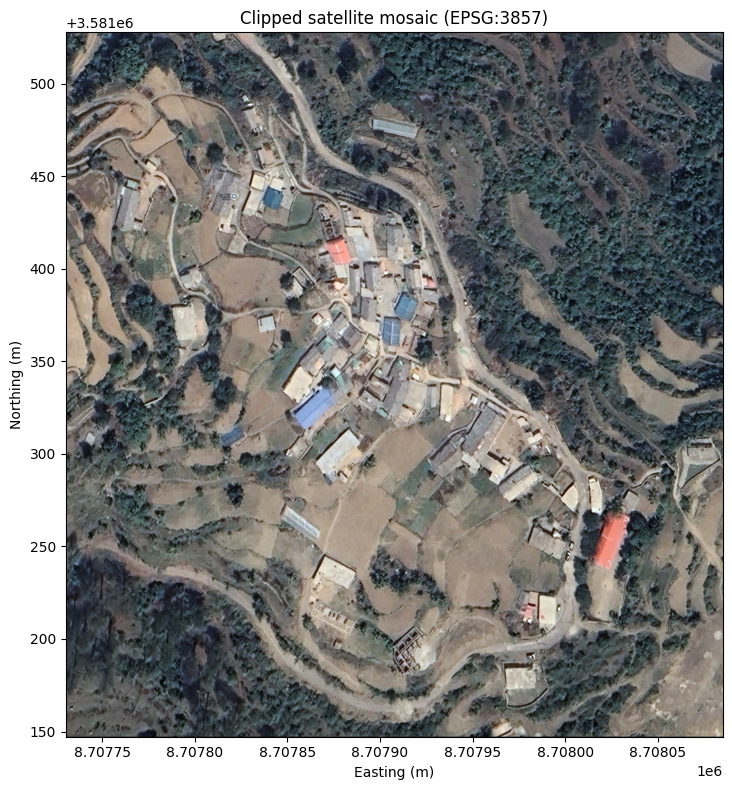

(array([[[ 50,  49,  46, ...,  67,  72,  77],
         [ 54,  52,  48, ...,  57,  64,  72],
         [ 55,  50,  43, ...,  53,  56,  68],
         ...,
         [ 67,  74,  77, ..., 161, 163, 165],
         [ 76,  82,  85, ..., 158, 161, 163],
         [  0,   0,   0, ...,   0,   0,   0]],
 
        [[ 70,  69,  65, ...,  72,  77,  82],
         [ 74,  72,  67, ...,  62,  69,  77],
         [ 75,  70,  62, ...,  58,  61,  73],
         ...,
         [ 66,  73,  76, ..., 153, 155, 157],
         [ 75,  81,  84, ..., 150, 153, 155],
         [  0,   0,   0, ...,   0,   0,   0]],
 
        [[ 81,  76,  72, ...,  76,  81,  86],
         [ 85,  79,  74, ...,  66,  73,  81],
         [ 86,  77,  69, ...,  62,  65,  77],
         ...,
         [ 61,  68,  71, ..., 134, 136, 138],
         [ 70,  76,  79, ..., 131, 134, 136],
         [  0,   0,   0, ...,   0,   0,   0]]], dtype=uint8),
 Affine(0.14929107086863952, 0.0, 8707730.148818618,
        0.0, -0.1492910708693671, 3581527.724269526))

In [9]:

mosaic, transform = build_mosaic(BBOX, ZOOM)
write_and_clip(mosaic, transform, BBOX, OUT_TIF, OUT_JPG)